# WISDM Dataset 기반 ResNet 분류

##결과 분석

Test accuracy: 95.34%

WISDM 데이터셋을 ResNet 기반 모델로 학습한 결과 정확도는 95.34%로 나타났다.

ResNet은 Conv1D 기반 residual block을 통해 센서 신호의 짧은 구간의 패턴을 효과적으로 추출하여 RNN과 LSTM보다 높은 성능을 보였다.

실험 결과 Sitting, Standing, Walking, Jogging은 높은 precision과 recall을 보였고 특히 정적 활동인 Sitting과 Standing은 거의 완벽하게 분류되었다.

또한 RNN과 LSTM에서 상대적으로 어려웠던 Upstairs와 Downstairs도 recall 0.85 수준으로 개선되었다.

따라서 WISDM 데이터셋에서는 ResNet이 RNN, LSTM보다 짧은 구간의 패턴을 더 효과적으로 학습하는 ResNet 구조가 더 적합하다고 판단된다.

In [1]:
# Library imports
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout,
    Conv1D, BatchNormalization, ReLU,
    MaxPooling1D, GlobalAveragePooling1D,
    Add, GaussianNoise
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity -> 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26
  - 27 ≤ user_id ≤ 31
  - user_id ≥ 32
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [4]:
# raw 데이터 로드
# WISDM raw data는 컬럼명이 없는 형태
# 각 칼럼에 이름 지정
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";") # 세미콜론 이후 내용 무시
print(data.head())


   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [5]:
# 클린업
# 문자열 값을 float32 숫자형으로 변환
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

# 앞에서 raw data를 읽을 때 생긴 불필요한 NaN 컬럼 제거
df = data.drop('NaN', axis=1)
# 결측값 행 제거
df = df.dropna()

# 세미콜론 제거
df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
# x, y, z축 가속도 값을 문자열에서 float32 숫자형으로 변환
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [6]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))



Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [7]:
# Data Split (user_id 기반)
# user_id가 26 이하 = train set
df_train = df[df['user_id'] <= 26]
# user_id가 27~31인 = validation set
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
# user_id가 32 이상 = test set
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")



Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [8]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])


In [9]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    # 전체 데이터를 time_steps 길이만큼 자르고 step 간격으로 이동
    for i in range(0, len(x) - time_steps, step):
        # 현재 window에 해당하는 x/y/z 센서 값 추출
        v = x.iloc[i:i + time_steps].values
        # 현재 window 안에 포함된 activity label 추출
        labels = y.iloc[i:i + time_steps]
        # window 내부에서 가장 많이 등장한 label을 대표 label로 사용
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [10]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록 만드는 역할
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## ResNet Model
- Residual blocks (Conv1D + Skip connection)
- GaussianNoise for regularization
- GlobalAveragePooling1D classifier head

In [11]:
# Residual Block 정의
def residual_block(x, filters, kernel_size=3, pool=True):
    shortcut = x

    if x.shape[-1] != filters:
        shortcut = Conv1D(filters, kernel_size=1, padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = Conv1D(filters, kernel_size=kernel_size, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)

    x = Add()([x, shortcut])
    x = ReLU()(x)

    if pool:
        x = MaxPooling1D(pool_size=2)(x)

    return x


# ResNet 모델 정의
def build_resnet_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = GaussianNoise(0.01)(inputs)

    x = Conv1D(64, kernel_size=7, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling1D(pool_size=2)(x)

    x = residual_block(x, filters=64,  kernel_size=3, pool=False)
    x = residual_block(x, filters=64,  kernel_size=3, pool=False)

    x = residual_block(x, filters=128, kernel_size=3, pool=True)
    x = residual_block(x, filters=128, kernel_size=3, pool=False)

    x = residual_block(x, filters=256, kernel_size=3, pool=True)
    x = residual_block(x, filters=256, kernel_size=3, pool=False)

    x = GlobalAveragePooling1D()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)


# 모델 생성 및 컴파일
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model = build_resnet_model(input_shape, num_classes)

model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 200, 3)    │          0 │ input_layer[0][0] │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 64)   │      1,344 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 200, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 100, 64)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 100, 64)   │     12,288 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 100, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 100, 64)   │     12,288 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 100, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 100, 64)   │     12,288 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 100, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 100, 64)   │     12,288 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 100, 64)   │          0 │ add_1[0][0]     

 Total params: 1,060,038 (4.04 MB)

 Trainable params: 1,055,558 (4.03 MB)

 Non-trainable params: 4,480 (17.50 KB)

None


In [12]:
callbacks = [
    ModelCheckpoint(
        "WISDM_HAR_ResNet_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.8506 - sparse_categorical_accuracy: 0.6929
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.52317, saving model to WISDM_HAR_ResNet_best.h5



Epoch 1: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - loss: 0.4603 - sparse_categorical_accuracy: 0.8466 - val_loss: 2.0747 - val_sparse_categorical_accuracy: 0.5232
Epoch 2/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1245 - sparse_categorical_accuracy: 0.9705
Epoch 2: val_sparse_categorical_accuracy improved from 0.52317 to 0.75024, saving model to WISDM_HAR_ResNet_best.h5



Epoch 2: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.1334 - sparse_categorical_accuracy: 0.9720 - val_loss: 2.3988 - val_sparse_categorical_accuracy: 0.7502
Epoch 3/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0926 - sparse_categorical_accuracy: 0.9770
Epoch 3: val_sparse_categorical_accuracy improved from 0.75024 to 0.75244, saving model to WISDM_HAR_ResNet_best.h5



Epoch 3: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0880 - sparse_categorical_accuracy: 0.9799 - val_loss: 1.7562 - val_sparse_categorical_accuracy: 0.7524
Epoch 4/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0722 - sparse_categorical_accuracy: 0.9856
Epoch 4: val_sparse_categorical_accuracy improved from 0.75244 to 0.77366, saving model to WISDM_HAR_ResNet_best.h5



Epoch 4: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0728 - sparse_categorical_accuracy: 0.9841 - val_loss: 1.5695 - val_sparse_categorical_accuracy: 0.7737
Epoch 5/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0557 - sparse_categorical_accuracy: 0.9883
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.77366
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0544 - sparse_categorical_accuracy: 0.9892 - val_loss: 2.4391 - val_sparse_categorical_accuracy: 0.6517
Epoch 6/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0682 - sparse_categorical_accuracy: 0.9847
Epoch 6: val_sparse_categorical_accuracy did not improve from 0.77366
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0637 - sparse_categorical_accuracy: 0.9863 - val_loss: 1.4565 - val_sparse_categorical_accuracy: 0.7393
Epoch 7/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0527 - sparse_categorical_accuracy: 0.9890
Epoch 7: va

...


Epoch 9: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0615 - sparse_categorical_accuracy: 0.9857 - val_loss: 1.1052 - val_sparse_categorical_accuracy: 0.7895
Epoch 10/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0521 - sparse_categorical_accuracy: 0.9890
Epoch 10: val_sparse_categorical_accuracy did not improve from 0.78951
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0591 - sparse_categorical_accuracy: 0.9884 - val_loss: 1.4294 - val_sparse_categorical_accuracy: 0.7441
Epoch 11/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0414 - sparse_categorical_accuracy: 0.9911
Epoch 11: val_sparse_categorical_accuracy improved from 0.78951 to 0.78976, saving model to WISDM_HAR_ResNet_best.h5



Epoch 11: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0451 - sparse_categorical_accuracy: 0.9906 - val_loss: 1.8250 - val_sparse_categorical_accuracy: 0.7898
Epoch 12/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0563 - sparse_categorical_accuracy: 0.9888
Epoch 12: val_sparse_categorical_accuracy did not improve from 0.78976
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0558 - sparse_categorical_accuracy: 0.9892 - val_loss: 1.7892 - val_sparse_categorical_accuracy: 0.7488
Epoch 13/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0406 - sparse_categorical_accuracy: 0.9919
Epoch 13: val_sparse_categorical_accuracy improved from 0.78976 to 0.79146, saving model to WISDM_HAR_ResNet_best.h5



Epoch 13: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0407 - sparse_categorical_accuracy: 0.9922 - val_loss: 1.4578 - val_sparse_categorical_accuracy: 0.7915
Epoch 14/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0376 - sparse_categorical_accuracy: 0.9929
Epoch 14: val_sparse_categorical_accuracy did not improve from 0.79146
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0333 - sparse_categorical_accuracy: 0.9928 - val_loss: 1.5354 - val_sparse_categorical_accuracy: 0.7641
Epoch 15/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0331 - sparse_categorical_accuracy: 0.9895
Epoch 15: val_sparse_categorical_accuracy improved from 0.79146 to 0.81000, saving model to WISDM_HAR_ResNet_best.h5



Epoch 15: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0360 - sparse_categorical_accuracy: 0.9909 - val_loss: 1.9043 - val_sparse_categorical_accuracy: 0.8100
Epoch 16/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0235 - sparse_categorical_accuracy: 0.9952
Epoch 16: val_sparse_categorical_accuracy did not improve from 0.81000
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0246 - sparse_categorical_accuracy: 0.9943 - val_loss: 3.4661 - val_sparse_categorical_accuracy: 0.7300
Epoch 17/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0338 - sparse_categorical_accuracy: 0.9932
Epoch 17: val_sparse_categorical_accuracy did not improve from 0.81000
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0353 - sparse_categorical_accuracy: 0.9917 - val_loss: 2.5242 - val_sparse_categorical_accuracy: 0.7788
Epoch 18/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0437 - sparse_categorical_accuracy: 0.9885
Epoch


Epoch 28: finished saving model to WISDM_HAR_ResNet_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0226 - sparse_categorical_accuracy: 0.9952 - val_loss: 1.5179 - val_sparse_categorical_accuracy: 0.8105
Epoch 29/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0228 - sparse_categorical_accuracy: 0.9956
Epoch 29: val_sparse_categorical_accuracy did not improve from 0.81049
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0300 - sparse_categorical_accuracy: 0.9942 - val_loss: 3.2178 - val_sparse_categorical_accuracy: 0.6846
Epoch 30/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0314 - sparse_categorical_accuracy: 0.9921
Epoch 30: val_sparse_categorical_accuracy did not improve from 0.81049
305/305 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0224 - sparse_categorical_accuracy: 0.9946 - val_loss: 2.0709 - val_sparse_categorical_accuracy: 0.7805
Epoch 31/100
301/305 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0240 - sparse_categorical_accuracy: 0.9941
Epoch

In [13]:
# Model evaluation
model = tf.keras.models.load_model("WISDM_HAR_ResNet_best.h5")

train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.91%
Training loss: 0.0036
Test accuracy: 95.34%
Test loss: 0.3563


In [14]:
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

  Downstairs       0.84      0.85      0.84       346
     Jogging       1.00      0.95      0.97      1316
     Sitting       1.00      1.00      1.00       300
    Standing       0.99      1.00      1.00       189
    Upstairs       0.82      0.85      0.83       384
     Walking       0.97      0.99      0.98      1350

    accuracy                           0.95      3885
   macro avg       0.94      0.94      0.94      3885
weighted avg       0.95      0.95      0.95      3885



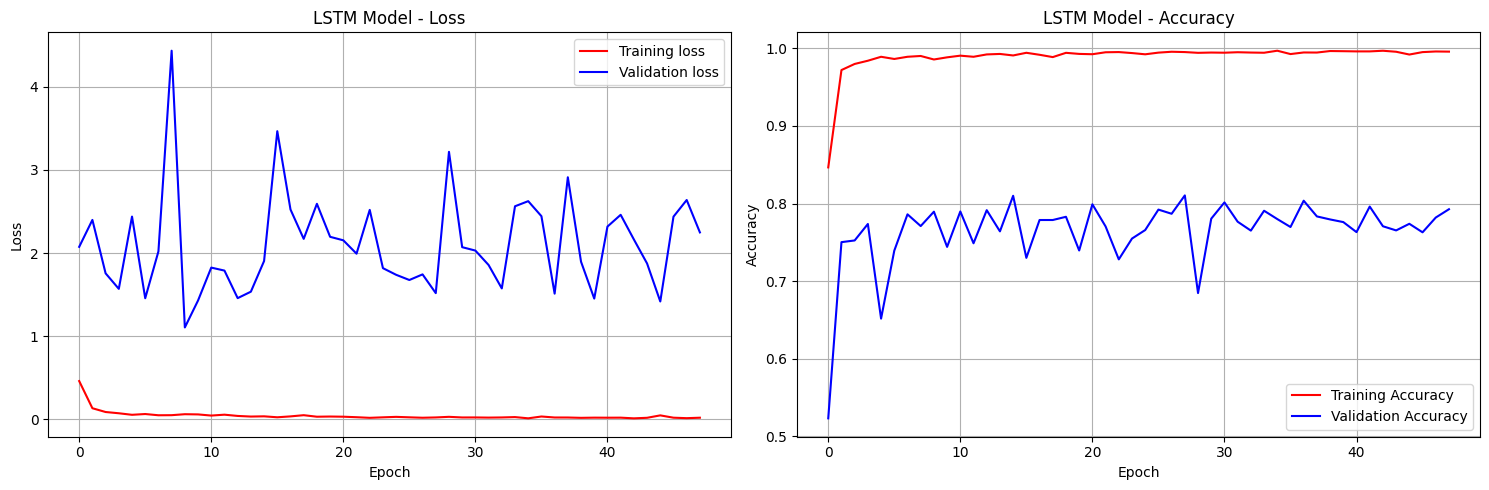

In [15]:
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('LSTM Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('LSTM Model - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

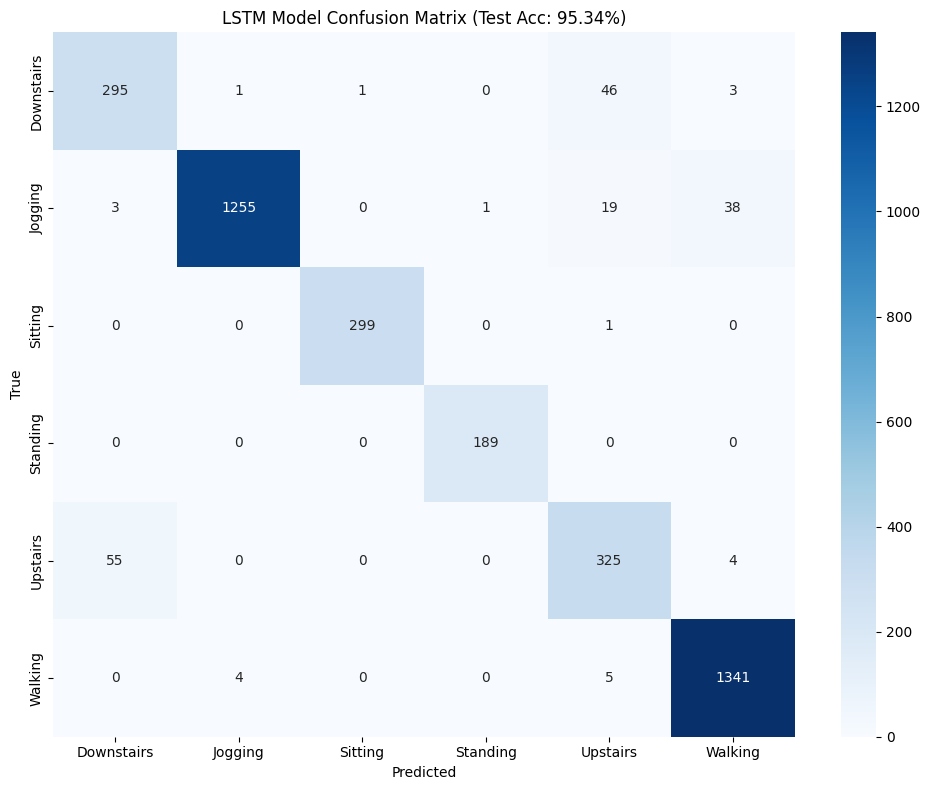

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'LSTM Model Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()